### Synthetic Validation

We created a synthetic suite, designed to manifest Real Concept Drift (where the relationship $P(Y|X)$ changes) by defining anomalies relative to an evolving local distribution. The base signal is $T_i = \mu_i + \epsilon_i + s_i$ with $\epsilon_i \sim \mathcal{N}(0, 0.1)$ and sparse spikes $s_i$ the labeled anomalies (for $i \in [0, n-1]$, where $n=|T|$ the length of the time series). We validated our methodology across the following scenarios:
* **Continuous Drift:** Linear mean evolution,  $\mu_i = \delta i, \delta = 3/n$.
* **Change Point (Mean):** An abrupt regime shift at midpoint, $\mu_i = 0$ if $i < n/2$ else $2.5$.
* **Periodic Drift:** Toggling distribution parameters every $2 \times t_r$ steps,$\mu_i = 2$ if $\lfloor i/2t_r \rfloor$ is odd else $0$.
* **Random Walk:** Stochastic non-stationarity, $\mu_i = \sum_{k=1}^i \eta_k, \eta_k \sim \mathcal{N}(0, 0.05)$.
* **Virtual Drift (Noise Shift):** To ensure our threshold distinguishes between CD and simple noise increases, we simulated a variance shift: $\sigma = 0.1 \to 0.4$ at $i=n/2$ ($\mu_i$ constant).

**Results:** Our JSD methodology successfully localized the "ground truth" drift points in 100% of the CD scenarios while correctly identifying the Virtual Drift as a lower-magnitude shift (JSD=0.3) that does not fundamentally alter the anomaly-to-normal relationship.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import glob
import os

In [ ]:
def inject_anomalies(n, rng, anomaly_prob=0.005):
    """Generates a binary mask and significant spikes."""
    mask = np.zeros(n, dtype=int)
    anom_indices = rng.choice(n, int(n * anomaly_prob), replace=False)
    mask[anom_indices] = 1
    
    spikes = np.zeros(n)
    spikes[anom_indices] = rng.choice([-1, 1], len(anom_indices)) * 4.0
    return spikes, mask

def generate_strad_synt(N=5000, tr=500, seed=42):
    os.makedirs('Datasets/synt', exist_ok=True)
    
    rng = np.random.default_rng(seed)
    base_sigma = 0.1
    
    scenarios = ['Stationary', 'Continuous', 'ChangePoint', 'ChangePointNoise', 'Periodic', 'RandomWalk']
    
    for name in scenarios:
        d1 = rng.normal(0, base_sigma, N)
        d2 = rng.normal(0, base_sigma, N)
        d3 = rng.normal(0, base_sigma, N)

        if name == 'Continuous':
            trend = np.linspace(0, 3.0, N)
            d1 += trend
            
        elif name == 'ChangePoint':
            mid = N // 2
            d1[mid:] += 2.5
        
        elif name == 'ChangePointNoise':
            mid = N // 2
            d1[mid:] = rng.normal(0, 0.4, N - mid)
            
        elif name == 'Periodic':
            period = 2 * tr
            for i in range(N):
                if (i // period) % 2 == 1:
                    d1[i] += 2.0
                    
        elif name == 'RandomWalk':
            rw = np.cumsum(rng.normal(0, 0.05, N))
            d1 += rw

        all_dims = []
        all_masks = []
        for base_sig in [d1, d2, d3]:
            spikes, mask = inject_anomalies(N, rng)
            all_dims.append(base_sig + spikes)
            all_masks.append(mask)

        global_label = np.max(all_masks, axis=0)

        df = pd.DataFrame({
            'D1': all_dims[0], 'D2': all_dims[1], 'D3': all_dims[2],
            'Label': global_label
        })
        
        filename = f"Datasets/synt/strad_synt_{name.lower()}_tr_{tr}_1st_x.csv"
        df.to_csv(filename, index=False)
        print(f"Generated: {filename}")

In [ ]:
# For example
generate_strad_synt(seed=26)

Generated: Datasets/synt/strad_synt_stationary_tr_500_1st_x.csv
Generated: Datasets/synt/strad_synt_continuous_tr_500_1st_x.csv
Generated: Datasets/synt/strad_synt_changepoint_tr_500_1st_x.csv
Generated: Datasets/synt/strad_synt_changepointnoise_tr_500_1st_x.csv
Generated: Datasets/synt/strad_synt_periodic_tr_500_1st_x.csv
Generated: Datasets/synt/strad_synt_randomwalk_tr_500_1st_x.csv


In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12})

def visualize_strad_sim_with_train_highlight():
    folder = "Datasets/synt"
    train_size = 500
    
    search_pattern = os.path.join(folder, "strad_synt_*_tr_500_1st_x.csv")
    files = sorted(glob.glob(search_pattern))
    
    if not files:
        print(f"No files found in '{folder}/' matching the pattern. Check your directory!")
        return

    fig, axes = plt.subplots(len(files), 1, figsize=(12, 18), sharex=True)
    
    # If only one file is found, axes is not a list
    if len(files) == 1: axes = [axes]

    for i, file in enumerate(files):
        # Extract scenario name from the middle of the filename
        # e.g. strad_synt_continuous_tr_500_1st_x.csv -> Continuous
        filename = os.path.basename(file)
        scenario_name = filename.split('_')[2].capitalize()
        
        df = pd.read_csv(file)
        ax = axes[i]
        
        # 1. Highlight the Training/Reference Batch (B0) in Green
        # This covers the first 500 samples
        ax.axvspan(0, train_size, color='green', alpha=0.15, label='Training Batch (B0)')
        
        # 2. Plot Background Normal Signals
        ax.plot(df['D2'], color='gray', alpha=0.2, linewidth=0.8, label='D2 (Stationary)')
        ax.plot(df['D3'], color='silver', alpha=0.2, linewidth=0.8, label='D3 (Stationary)')
        
        # Plot D1 in a bold color
        ax.plot(df['D1'], color='#1f77b4', alpha=0.8, linewidth=1.2, label='D1 (Target)')
        
        # 3. Highlight Anomalies in Red
        anomalies = df[df['Label'] == 1]
        if not anomalies.empty:
            ax.scatter(anomalies.index, anomalies['D1'], color='red', s=15, marker='o', label='Anomaly (Label=1)', zorder=5)
        
        ax.set_title(f"Scenario: {scenario_name}", loc='left', fontweight='bold')
        ax.set_ylabel("Value")
        
        # Legend only on the first plot to avoid clutter
        if i == 0:
            ax.legend(loc='upper right', ncol=5, fontsize='x-small', frameon=True)
            
    axes[-1].set_xlabel("Time (Samples)")
    plt.tight_layout()
    
    save_path = "strad_sim_final_viz.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"Visualization with Training Highlight saved as '{save_path}'.")


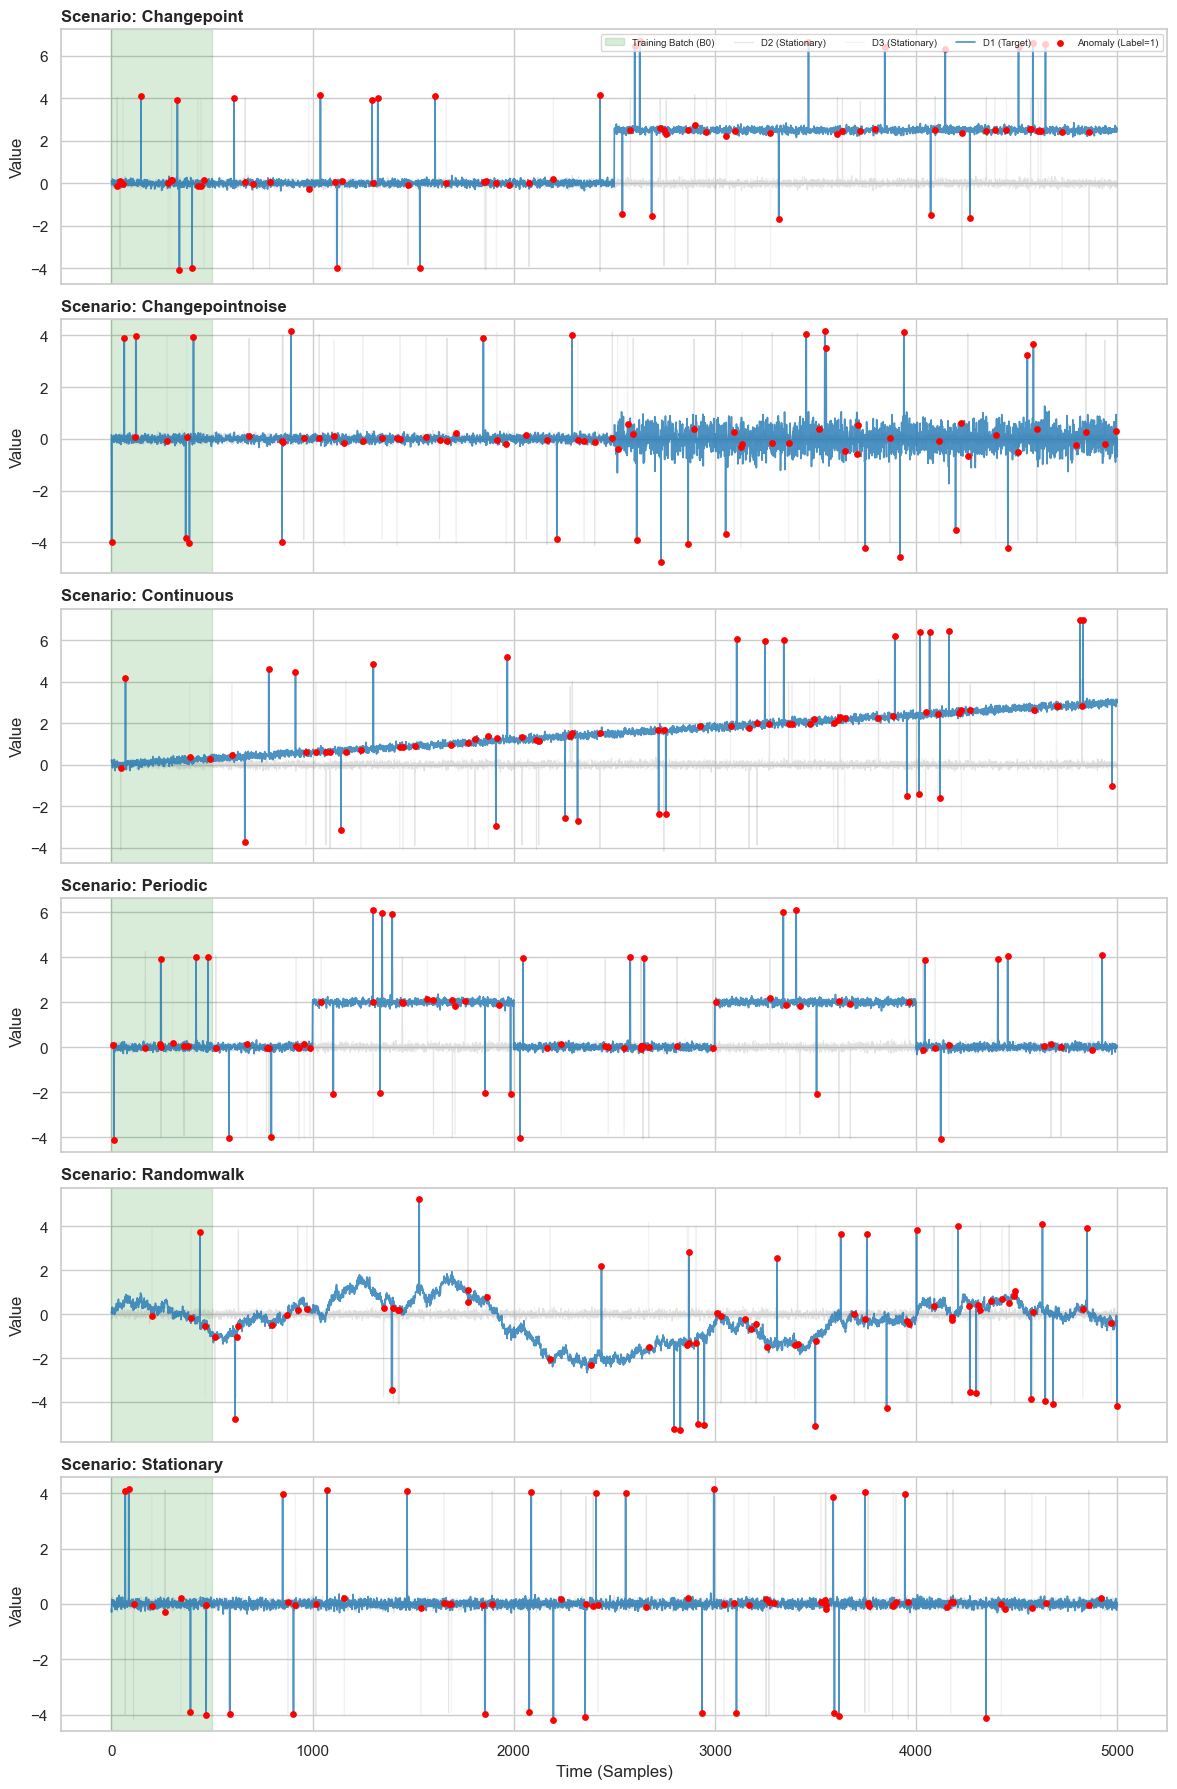

In [10]:
visualize_strad_sim_with_train_highlight()